<figure>
  <img src="../images/tudelft_logo.png" alt="image" width="250" align="right"/>
</figure>

# 4a: Bound long waves

Welcome at this first notebook of week 4 on bound long waves. When we discussed radiation stress in Notebook 3c, we did not consider the variations of radiation stress and wave forces *within a wave group* yet. We will do so in this Notebook. 

Due to the wave height variations within a group, the wave energy and radiation stresses vary as well. In this notebook, our starting point is the expression for the wave envelope that we dealt with in Notebook 2a. We will use this envelope to determine how the wave energy and radiation stress vary within a wave group and how this forces a long wave motion on the scale of a wave group. 

This notebook consists of two parts:
1. Part 1: Slowly-varying wave energy and radiation stress (coding exercises and one multiple-choice and one multiple-selection question)
2. Part 2: Bound long wave (coding exercises and one multiple-selection question)

## Theory
In Notebook 2b, we considered a bichromatic wave train on a horizontal bed, with the frequencies of the components close together, and equal amplitudes. This resulted in a wave group consisting of a so-called carrier wave $\sin(\bar\omega t - \bar k x)$ with a slowly-varying amplitude $a(x,t)$ given as: 

\begin{equation}
\tag{1}
A (x,t)  =  2a \cos(\frac{\Delta\omega}{2}t - \frac{\Delta k}{2}x)
\end{equation}

So far, for instance in Notebook 3c, we have considered the wave energy $E$ as a resultant quantity integrated over the wave period and any wave groups: $E=\bar E$. In this notebook, however, we will consider the temporal variation *within* the wave group by taking into account the slowly-varying amplitude $a (x,t)$. We get:

\begin{equation}
\tag{2}
E (x,t) =  \frac{1}{2} \rho g a(x,t)^2
\end{equation}

The radiation stress $S_{xx}$ varies as:

\begin{equation}
\tag{4}
S_{xx} (x,t) =  (2 n - 0.5) E(x,t) 
\end{equation}

with: 

\begin{equation}
\tag{5}
n = \frac{c_g}{\bar c} \mathrm{\enspace with \enspace} c_g = \frac{\Delta\omega }{\Delta k} \mathrm{\enspace and \enspace} \bar c = \frac{\bar \omega }{ \bar k }
\end{equation}

In Part 1 of this Notebook, we will determine $E(x,t)$ and $S_{xx}(x,t)$. In part 2 we will see how this time-variation forces a bound long wave associated with the group.

## Import libraries that we use for our analysis
Let's first import the libraries that we use for our analysis by running the next cells.

In [1]:
from pathlib import Path

import numpy as np
import holoviews as hv
from IPython.display import display 
import panel as pn

import coastal_dynamics as cd

pn.extension()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
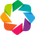

In [2]:
import sys

sys.path.append('../')

from modules import mod_4a

In [3]:
questions = cd.read_questions(Path("../hashed_questions/4a_bound_long_wave_hashed.json"))

question_industry = cd.QuestionIndustry(questions)

cd.UseAnswersApp("Q4a").serve()

Column
    [0] Markdown(str)
    [1] Button(name='Help')
    [2] StaticText(value=' ')
    [3] Row
        [0] Button(name='Disregard saved answers')
        [1] Button(button_type='danger', name='Are you sure?', visible=False)
    [4] StaticText(value=' ')
    [5] ParamFunction(function, _pane=Str, defer_load=False)

## Fenton approximation

Also in this notebook, you will need the Fenton approximation for solving the dispersion relationship. Copy your code in the below cell.


In [4]:
## Fenton approximation to the linear dispersion relationship
def waveNumber_Fenton(T, h):
    """Complete the code here"""
    k = None
    
    return k



## Part 1: Slowly-varying wave energy and radiation stress

In Notebook 2b, we discussed the wave group and wave envelope for two harmonic components with equal amplitude, and you coded functions for the surface elevation and wave envelope yourself. Below we will assume that you know how to determine the wave envelope and continue from there. 

### Exercise

Can you code the wave energy $E(x,t)$ and radiation stresses and $S_{xx}(x,t)$ as they vary within the bichromatic wave group with equal amplitudes? In the below code cell you are asked to provide two functions for the wave energy: $E(x = x_p, t)$ and $E(x,t = t_p)$ and two functions for the radiation stress: $S_{xx}(x = x_p, t)$ and $S_{xx}(x,t = t_p)$. Your functions will be checked automatically and plotted together with the correct functions. It is also possible to first run the code cell without already supplying your own functions, so that you can get an idea of what the resulting plot should look like. 

NB. In your function you can call your above defined Fenton function as follows: "k = waveNumber_Fenton(T, h)".

In [5]:
input_values = {
    "a": 1,                          # amplitude of second harmonic component [m]
    "T1": 5,                         # period of first harmonic component [s]
    "T2": 4.5,                       # period of second harmonic component [s]
    "tp": 0,                         # constant t-value for spatial plot (0 is default)
    "xp": 0,                         # constant x-value for time plot (0 is default)
    "t": [],                         # t-range, will be determined automatically to cover n_groups wave groups starting from t = 0 
    "x": [],                         # x-range, will be determined automatically to cover n_groups wave groups starting from x = 0 
    "h": 7,                          # water depth [m]
    "n_groups": 4,                   # number of wave groups that will be shown in time and space [-] (axes start from 0)   
    "rho": 1025,                     # density of the water [kg/m^3]
    "g": 9.81,                       # acceleration due to gravity [m/s^2]
}

def Energy_Radiation_Stress(a, T1, T2, tp, xp, t, x, h, rho, g):
    """  
    Args:
        see definition at input_values
        
    Returns:
        E_t: Calculated time-varying wave energy for x = xp, E(x = xp, t) (referred to as Function 1).
        E_x: Calculated spatially-varying wave energy for t = tp, E(x,t = tp) (referred to as Function 2).
        Sxx_t: Calculated time-varying radiation stress for x = xp, Sxx(x = xp, t) (referred to as Function 3).    
        Sxx_x: Calculated spatially-varying radiation stress for t = tp, Sxx(x,t = tp) (referred to as Function 4).    
    """
    
    E_t = None  # Replace None by your own function 1
    E_x = None  # Replace None by your own function 2
    Sxx_t = None  # Replace None by your own function 3
    Sxx_x = None  # Replace None by your own function 4

    
    return E_t, E_x, Sxx_t, Sxx_x  

output, figure = mod_4a.check_envelope_E(input_values, Energy_Radiation_Stress)

print(output)
display(figure)

Your function is: 
Function 1 is incorrect.
Function 2 is incorrect.
Function 3 is incorrect.
Function 4 is incorrect.



:Layout
   .Overlay.I   :Overlay
      .Curve.Η              :Curve   [x]   (y)
      .Curve.Upper_envelope :Curve   [x]   (y)
      .Curve.Lower_envelope :Curve   [x]   (y)
   .Overlay.II  :Overlay
      .Curve.Η              :Curve   [x]   (y)
      .Curve.Upper_envelope :Curve   [x]   (y)
      .Curve.Lower_envelope :Curve   [x]   (y)
   .Overlay.III :Overlay
      .Curve.Student_E_t_equals_E_left_parenthesis_x_equals_xₚ_comma_t_right_parenthesis :Curve   [x]   (y)
      .Curve.Correct_E_t_equals_E_left_parenthesis_x_equals_xₚ_comma_t_right_parenthesis :Curve   [x]   (y)
   .Overlay.IV  :Overlay
      .Curve.Student_E_x_equals_E_left_parenthesis_x_comma_t_equals_tₚ_right_parenthesis :Curve   [x]   (y)
      .Curve.Correct_E_x_equals_E_left_parenthesis_x_comma_t_equals_tₚ_right_parenthesis :Curve   [x]   (y)
   .Overlay.V   :Overlay
      .Curve.Student_Sxx_t_equals_Sₓₓ_left_parenthesis_x_equals_xₚ_comma_t_right_parenthesis :Curve   [x]   (y)
      .Curve.Correct_Sxx_t_equals_Sₓₓ_left_parenthesis_x_equals_xₚ_comma_t_right_parenthesis :Curve   [x]   (y)
   .Overlay.VI  :Overlay
      .Curve.Student_Sxx_x_equals_Sₓₓ_left_parenthesis_x_comma_t_equals_tₚ_right_parenthesis :Curve   [x]   (y)
      .Curve.Correct_Sxx_x_equals_Sₓₓ_left_parenthesis_x_comma_t_equals_tₚ_right_parenthesis :Curve   [x]   (y)

In [6]:
# Run this cell to get questions about Part 1

q = [
    "Q4a_part1_radiation_stress_variation",
    "Q4a_part1_set_down_variation"
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-1', sizing_mode='stretch_width', value='What did you l...)
        [1] CheckBoxGroup(name='Options', options=['Sₓₓ is highest under the...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)
    [1] Column(width_policy='max')
        [0] StaticText(name='Q-2', sizing_mode='stretch_width', value='Could you reason w...)
        [1] RadioBoxGroup(name='Options', options=['The highest mean water l...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

### Rewrite formulations for wave energy and radiation stress

The variation of $E$ and $S_{xx}$ in a wave group can be better understood if we rewrite Eqs. (2) and (4). Since $\cos^2x = \frac{1}{2}(\cos2x + 1)$, we can write: 

\begin{equation}
\tag{6}
E (x,t) =  2 \rho g a^2 \cos^2 (\frac{\Delta\omega}{2}t - \frac{\Delta k}{2}x) =  \rho g a^2 \left( 1 + \cos (\Delta\omega t - \Delta k x) \right)
\end{equation}

Clearly, the wave energy consists of a mean part $\bar E = \rho g a^2$ and a fluctuating part $\tilde E =  \rho g a^2 \cos (\Delta\omega t - \Delta k x)$.

Similarly, the radiation stress $S_{xx}$ consists of a mean part $\bar S_{xx}$ and a fluctuating part $\tilde S_{xx}$ and varies as:

\begin{equation}
\tag{7}
S_{xx} (x,t) =  (2 n - 0.5) E(x,t) =  \rho g a^2 (2 n - 0.5) \left( 1 + \cos (\Delta\omega t - \Delta k x) \right)
\end{equation}

From the term $\cos (\Delta\omega t - \Delta k x)$ in $\tilde E$ and $\tilde S_{xx}$ as well as from the above figures, we can see that the wave energy and radiation stresses fluctuate on the scale of the wave group ($\Delta\omega$, $\Delta k$).

## Part 2: Bound long wave

### Theory
In Notebook 3c, we have seen that the radiation stress gradients in the shoaling zone result in a set-down that increases towards the seaward edge of the surf zone. We found that this set-down depends on the wave height (see Section 5.5.4 and Equation 5.64 in the [Coastal Dynamics Open Textbook](https://books.open.tudelft.nl/home/catalog/book/202)). Due to *variation* of the wave height and radiation stresses in the groups, the set-down varies varies as well, being the largest under the highest waves. This results in a mean water level fluctuation on the scale of the wave group with the largest depression under the highest waves in the group. This is equivalent to a long wave motion, the so-called bound long wave, which is forced by the group and travels at the speed of this group (so $c_g$). For a perfect bound long wave, the phase-shift between the long wave and the short-wave envelope is $\pi$ ; the wave trough of the bound long waves coincides with the maximum of the wave envelope and the wave crest coincides with the minimum of the wave envelope. This negative correlation changes to a positive correlation as the waves enter the surf zone. This can be understood from intermittent wave-breaking in the group, generating a time-varying set-up. See also Section 5.8.2 in the textbook.

In summary, the bound long wave varies on the scale of the wave group, as the wave energy and radiation stress do. We can thus write for the bound long wave:

\begin{equation}
\tag{8}
\eta_b = \hat\eta_b \cos (\Delta\omega t - \Delta k x)
\end{equation}

In here, the bound long wave surface elevation amplitude $\hat\eta_b$ must be *negative*. Can you see why?

A formula for the bound long wave surface elevation amplitude for this situation was derived by Longuet-Higgins and Stewart (1962). It can be found as Eq. 3.134 in a Guide to Modeling Coastal Morphology by Dano Roelvink and Ad Reniers. It reads:

\begin{equation}
\tag{9}
\hat\eta_b = \frac{\Delta k^2 ga^2 (2n-0.5)}{\Delta \omega^2-gh\Delta k^2} = \frac{-ga^2(2n-0.5)}{gh-\frac{\Delta \omega^2}{\Delta k^2}} = \frac{-ga^2(2n-0.5)}{gh-c_g^2}
\end{equation}

Verify for yourself that Eq. (9) will indeed yield a negative value!

### Exercise: bound long wave

Let's check whether Eqs. (8-9) make any sense. Do this by coding the bound long wave surface elevation. As before, you can code your function in the below code cell. By running this code cell, your code will automatically be checked and plotted in the figures, together with the correct answers. If you run the code cell without adjustments (so with "None" where your functions should appear), you will get a figure showing only the correct results.

Also, try to determine whereabout in the shoaling zone we are, for the given wave conditions. Can you change the water depth such, that the bound long wave amplitude becomes smaller? 

In [7]:
input_values = {
    "a": 1,                          # amplitude of second harmonic component [m]
    "T1": 5,                         # period of first harmonic component [s]
    "T2": 4.5,                       # period of second harmonic component [s]
    "tp": 0,                         # constant t-value for spatial plot (0 is default)
    "xp": 0,                         # constant x-value for time plot (0 is default)
    "t": [],                         # t-range, will be determined automatically to cover n_groups wave groups starting from t = 0 
    "x": [],                         # x-range, will be determined automatically to cover n_groups wave groups starting from x = 0 
    "h": 7,                          # water depth [m]
    "n_groups": 4,                   # number of wave groups that will be shown in time and space [-] (axes start from 0)   
    "rho": 1025,                     # density of the water [kg/m^3]
    "g": 9.81,                       # acceleration due to gravity [m/s^2]
}


def Bound_long_wave(a, T1, T2, tp, xp, t, x, h, rho, g):
    """  
    Args:
        see definition at input_values
        
    Returns:
        etab_t: Calculated time-varying long wave wave energy for x = xp, etab(x = xp, t) (referred to as Function 1).
        etab_x: Calculated spatially-varying long wave for t = tp, etab(x,t = tp) (referred to as Function 2).
    """
    
    etab_t = None  # Replace None by your own function 1
    etab_x = None  # Replace None by your own function 2

    
    return etab_t, etab_x

output, figure = mod_4a.check_boundwave_eta(input_values, Bound_long_wave)
print(output)
display(figure)

Your function is: 
Function 1 is incorrect.
Function 2 is incorrect.



:Layout
   .Overlay.I   :Overlay
      .Curve.Η                                                                               :Curve   [x]   (y)
      .Curve.Upper_envelope                                                                  :Curve   [x]   (y)
      .Curve.Lower_envelope                                                                  :Curve   [x]   (y)
      .Curve.Correct_etab_t_equals_ηb_left_parenthesis_x_equals_xₚ_comma_t_right_parenthesis :Curve   [x]   (y)
   .Overlay.II  :Overlay
      .Curve.Η                                                                               :Curve   [x]   (y)
      .Curve.Envelope                                                                        :Curve   [x]   (y)
      .Curve.Negative_envelope                                                               :Curve   [x]   (y)
      .Curve.Correct_etab_x_equals_ηb_left_parenthesis_x_comma_t_equals_tₚ_right_parenthesis :Curve   [x]   (y)
   .Overlay.III :Overlay
      .Curve.Student_etab_t_equals_ηb_left_parenthesis_x_equals_xₚ_comma_t_right_parenthesis :Curve   [x]   (y)
      .Curve.Correct_etab_t_equals_ηb_left_parenthesis_x_equals_xₚ_comma_t_right_parenthesis :Curve   [x]   (y)
   .Overlay.IV  :Overlay
      .Curve.Student_etab_x_equals_ηb_left_parenthesis_x_comma_t_equals_tₚ_right_parenthesis :Curve   [x]   (y)
      .Curve.Correct_etab_x_equals_ηb_left_parenthesis_x_comma_t_equals_tₚ_right_parenthesis :Curve   [x]   (y)

### Reflection
You can see in the figure that the trough of the bound long wave coincides with the maximum of the wave envelope and that the crest coincides with the minimum of the wave envelope. What would that mean for the direction of the orbital velocities of the bound long wave under the highest waves in the group? We are going to use this in chapter 7 to explain the role of long waves in cross-shore sediment transport.

In [8]:
# Run this cell to get a questions about Part 2

q = [
    "Q4a_part2_orbital_velocities"
]

question_industry.serve(q)

Column(width_policy='max')
    [0] Column(width_policy='max')
        [0] StaticText(name='Q-3', sizing_mode='stretch_width', value='How do the orbital v...)
        [1] CheckBoxGroup(name='Options', options=['The maximum onshore velo...])
        [2] Button(name='Submit', width=75)
        [3] StaticText(sizing_mode='stretch_width')
        [4] Markdown(None)

## The end 

You have reached the end of this Notebook 4a. You may proceed with the second and last notebook of this week on shallow-water tides.